#### HAR-RV + HMM 기반 Regime Leverage 전략 분석 보고서
#### 분석 목적
- 주식 지수의 변동성 상태(regime)을 판별하고 
- 저변동 구간에서는 레버리지를 증가 
- 고변동 구간에서는 숏 하지 않고 현금으로 대기
- 위험 관리 중심의 레버리지 전략 구축

#### 참고 기반 모델 
##### HAR-RV (Heterogeneous Autoregressive Realized volatility)
- 변동성은 단기, 중기, 장기의 이질적인 구조를 가진 다는 점을 반영하여, RV 예측 모델 중 가장 널리 사용된다 
##### 본 분석에서는 다음 변수를 사용한다
- Lagged RV 
- Weekly RV 
- Monthly RV 
- HAR-RV 모델은 로그 변동성에 대해 OLS로 회귀를 수행한다 
##### HMM (Hidden Markov Model)
- HAR-RV가 예측한 log-RV 를 입력으로 사용하여 
- 시장 변도성을 3개의 상태(low/mid/high)로 자동 분류한다 
 - 각 상태의 평균 log rv가 가장 낮으면 Low,
 - 가장 높으면 High
 - 나머지는 Mid 상태로 분류한다.

#### Regime 별 Target weight 설정 
- 변동성이 낮을 수록 시장은 추세적으로 상승할 가능성이 높다 -> 레버리지 1.3 
- 변동성이 높을 수록 급락/반등이 혼재한 혼란 구간 -> 숏 없이 현금 보유 
- SPY는 장기적으로 우상향 자산으로 숏 포지션은 구조적으로 불리하기 때문에 High 구간에서는 0% 

#### 모델 구성 절차 
- 데이터 
- 자산: SPY ETF 
- 기간: 최근 15년 
- RV :log-return ^2 로 계산 

##### HAR-RV 모델 
- Feature : rv_lag1, rv_weekly, rv_monthly 
- 예측 대상: log_rv 

##### HMM 모델 
- 입력 : HAR-RV 예측값 
- 상태수 : 3 
- 출력 : 날짜별 low/mid/high Regime 

##### 백테스트 
- Backtrader framework 사용 
- 매일 target_weight로 리밸런싱 
- 수수료 0.3% 
- 지표: Sharpe, CAGR, Drawdown, Total Return 

#### 성과 해석 
- Buy & Hold의 절대 수익률이 더 높다 → SPY는 장기 우상향 성격을 가진 자산이기 때문
- 하지만 Regime 전략은 Sharpe Ratio와 변동성 측면에서 우수
- High Vol 구간에서 Cash로 빠져 있었기 때문에 변동성을 절반 수준으로 낮추는 효과가 나타남

#### 전략의 한계 
- SPY 같이 우상향 하는 추세는 High Vol -> Cash가 상승 구간 일부를 놓침 
- HMM은 변동성 기반이라 모멘텀 활용이 어려움 
- Low Regime 의 레버리지가 다소 보수적임 

#### 향후 개선 방향 
- Low Regime 레버리지를 1.5~2.0 으로 상향 
- Mid Regime을 0.7-> 1.0으로 수정 
- 모멘텀 필터(50일 이동평균)를 추가하여 추세 구간 식별 
- High Vol 상태에서 TLT, VIX 롱 등을 결합하여 자산을 방어적으로 변환해볼 수 있을 것 


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     99.53
Date:                Sat, 20 Dec 2025   Prob (F-statistic):           5.50e-62
Time:                        00:00:01   Log-Likelihood:                -7530.2
No. Observations:                3750   AIC:                         1.507e+04
Df Residuals:                    3746   BIC:                         1.509e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.9206      0.033   -335.016      0.0

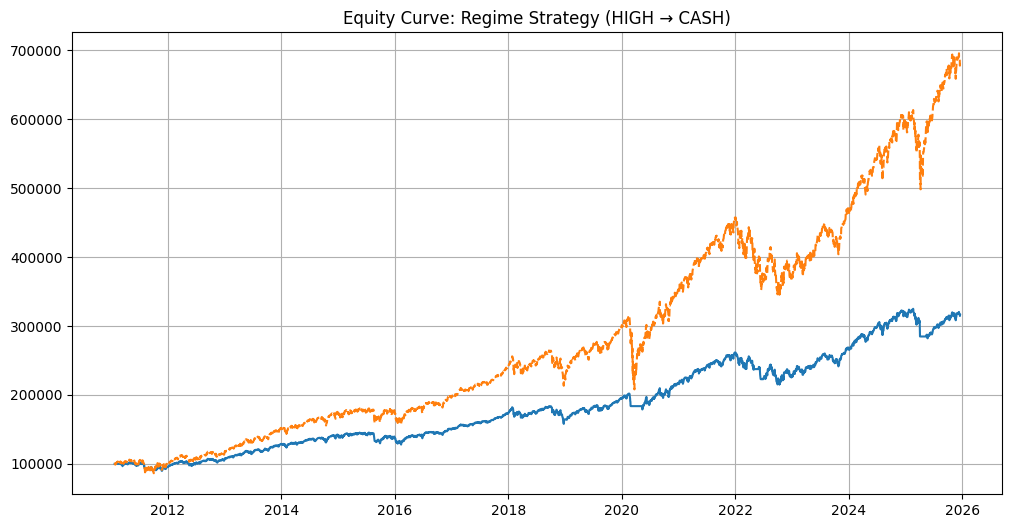

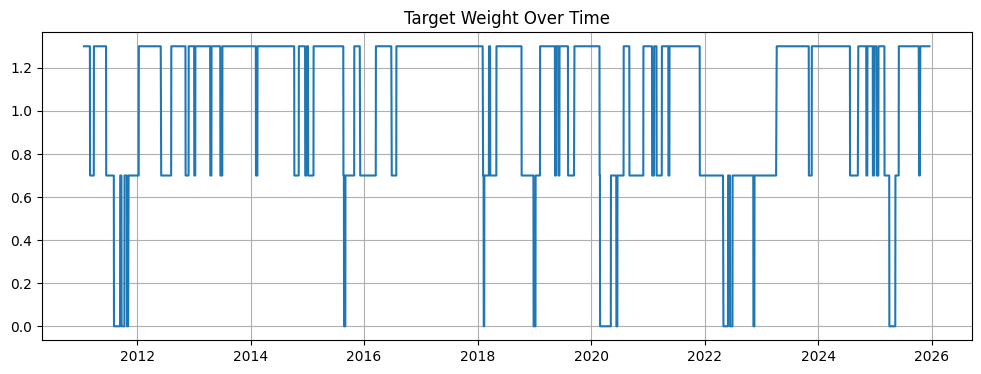


===== Performance Comparison Table =====
          Strategy    Final Value  Total Return      CAGR  Annual Volatility  \
0  Regime Strategy  316132.426442      2.161324  0.080416           0.099322   
1       Buy & Hold  682583.815683      5.825838  0.137772           0.172044   

   Sharpe (rf=0)  
0       0.809654  
1       0.800795  


In [6]:
# ============================================
# 0. IMPORT
# ============================================
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM

import backtrader as bt
import backtrader.analyzers as btanalyzers

import matplotlib.pyplot as plt


# ============================================
# 1. DATA DOWNLOAD
# ============================================
ticker = "SPY"
df = yf.download(ticker, period="15y", interval="1d", auto_adjust=True, progress=False)
df.dropna(inplace=True)

df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

rv_daily = pd.DataFrame(index=df.index)
rv_daily['RV'] = df['log_return'] ** 2


# ============================================
# 2. HAR-RV FEATURES
# ============================================
rv_df = rv_daily.copy().sort_index()
rv_df['rv_lag1']    = rv_df['RV'].shift(1)
rv_df['rv_weekly']  = rv_df['RV'].rolling(5).mean().shift(1)
rv_df['rv_monthly'] = rv_df['RV'].rolling(22).mean().shift(1)

har_df = rv_df.dropna().copy()


# ============================================
# 3. HAR REGRESSION
# ============================================
eps = 1e-6
X = har_df[['rv_lag1', 'rv_weekly', 'rv_monthly']].values
y = np.log(har_df['RV'].values + eps)

X_const = sm.add_constant(X)
har_model = sm.OLS(y, X_const).fit()
print(har_model.summary())

har_df['har_log_rv_pred'] = har_model.predict(X_const)
har_df['har_rv_pred']     = np.exp(har_df['har_log_rv_pred'])


# ============================================
# 4. HMM (3 STATE REGIME)
# ============================================
X_hmm = np.log(har_df['har_rv_pred'].values).reshape(-1, 1)

hmm = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    random_state=42
)
hmm.fit(X_hmm)

states = hmm.predict(X_hmm)
probs  = hmm.predict_proba(X_hmm)

state_means = hmm.means_.flatten()

low_vol_state  = np.argmin(state_means)
high_vol_state = np.argmax(state_means)

har_df["state"] = states
har_df["regime"] = har_df["state"].map({
    low_vol_state:  "LOW",
    high_vol_state: "HIGH"
}).fillna("MID")   # 나머지 state는 MID로


# ============================================
# 5. TARGET WEIGHT (HIGH = CASH)
# ============================================
def assign_weight(regime):
    if regime == "LOW":
        return 1.3     # 레버리지↑
    elif regime == "MID":
        return 0.7     # 보통 비중
    else:  # HIGH VOL
        return 0.0     # !!! CASH !!!
    
har_df['target_weight'] = har_df['regime'].apply(assign_weight)


# ============================================
# 6. MERGE DATA FOR BACKTRADER
# ============================================
daily_ohlc = df[['Open', 'High', 'Low', 'Close', 'Volume']]
daily_ohlc.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

bt_df = daily_ohlc.merge(
    har_df[['har_rv_pred', 'regime', 'target_weight']],
    left_index=True,
    right_index=True,
    how='inner'
)
bt_df.index.name = 'datetime'


# ============================================
# 7. BACKTRADER DATAFEED
# ============================================
class VolPandasData(bt.feeds.PandasData):
    lines = ("target_weight", )
    params = (
        ("datetime", None),
        ("open", "Open"),
        ("high", "High"),
        ("low", "Low"),
        ("close", "Close"),
        ("volume", "Volume"),
        ("openinterest", None),
        ("target_weight", "target_weight"),
    )


# ============================================
# 8. STRATEGY
# ============================================
class RegimeStrategy(bt.Strategy):
    params = dict()

    def __init__(self):
        self.tw = self.datas[0].target_weight

    def next(self):
        w = float(self.tw[0])
        self.order_target_percent(target=w)  # 매일 리밸런싱


# ============================================
# 9. BUY & HOLD
# ============================================
class BuyAndHold(bt.Strategy):
    def next(self):
        self.order_target_percent(target=1.0)


# ============================================
# 10. BACKTEST FUNCTION
# ============================================
def run_backtest(df, strategy_cls, cash=100000, commission=0.0003):
    cerebro = bt.Cerebro()
    cerebro.adddata(VolPandasData(dataname=df))
    cerebro.addstrategy(strategy_cls)

    cerebro.broker.setcash(cash)
    cerebro.broker.setcommission(commission=commission)
    cerebro.broker.set_coc(True)

    cerebro.addanalyzer(btanalyzers.SharpeRatio, _name="sharpe")
    cerebro.addanalyzer(btanalyzers.Returns, _name="returns")
    cerebro.addanalyzer(btanalyzers.DrawDown, _name="dd")
    cerebro.addanalyzer(btanalyzers.TimeReturn, _name="timereturn")

    print("\n[Backtest Start]", strategy_cls.__name__)
    res = cerebro.run()
    strat = res[0]

    # equity curve
    tr = strat.analyzers.timereturn.get_analysis()
    eq = pd.Series(tr)
    eq.index = pd.to_datetime(eq.index)
    eq = (1 + eq).cumprod() * cash

    return cerebro, strat, eq


# ============================================
# 11. PERFORMANCE SUMMARY FUNCTION
# ============================================
def summarize_performance(eq_curve, name):
    df = eq_curve.copy()
    total_return = df.iloc[-1] / df.iloc[0] - 1
    daily_ret = df.pct_change().dropna()

    # annual vol
    ann_vol = daily_ret.std() * np.sqrt(252)

    # CAGR
    cagr = (df.iloc[-1] / df.iloc[0]) ** (252/len(df)) - 1

    # Sharpe (assume rf=0)
    sharpe = cagr / ann_vol if ann_vol > 0 else np.nan

    summary = {
        "Strategy": name,
        "Final Value": df.iloc[-1],
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Volatility": ann_vol,
        "Sharpe (rf=0)": sharpe,
    }
    return summary


# ============================================
# 12. RUN + PLOT + SUMMARY TABLE
# ============================================
if __name__ == "__main__":
    cerebro_reg, strat_reg, eq_reg = run_backtest(bt_df, RegimeStrategy)
    cerebro_bh, strat_bh, eq_bh   = run_backtest(bt_df, BuyAndHold)

    # Equity Curve Plot
    equity_df = pd.concat(
        [eq_reg.rename("Regime"), eq_bh.rename("Buy&Hold")],
        axis=1
    ).dropna()

    plt.figure(figsize=(12, 6))
    plt.plot(equity_df.index, equity_df["Regime"])
    plt.plot(equity_df.index, equity_df["Buy&Hold"], linestyle="--")
    plt.title("Equity Curve: Regime Strategy (HIGH → CASH)")
    plt.grid(True)
    plt.show()

    # Target Weight Plot
    plt.figure(figsize=(12, 4))
    plt.plot(bt_df.index, bt_df["target_weight"])
    plt.title("Target Weight Over Time")
    plt.grid(True)
    plt.show()

    # Performance Summary Table
    summary_reg = summarize_performance(eq_reg, "Regime Strategy")
    summary_bh  = summarize_performance(eq_bh, "Buy & Hold")

    summary_df = pd.DataFrame([summary_reg, summary_bh])

    print("\n===== Performance Comparison Table =====")
    print(summary_df)

- Regime 전략은 변동성 9,9% 로 밴치 마크의 절반 수준으로 높은 안정성을 보임 
- 변동성 기반 Regime 전략이 buy & hold보다 소폭 높아, 더 좋은 위험조정 수익을 보임 
- 하지만 고변동 구간에서 현금으로 빠지기 때문에 buy & hold보다 상승장의 영향을 받지 못해 절대 수익이 낮음 